[materials @ 1575 nm] LN ne=2.136842 no=2.210268 | SiO2 n=1.443723 | Au eps=-120.37-11.93j
[geometry OK] 23 regions tile exactly
              SLAB_W 8.20 um (edge +2.00 um from the gap edge): slab ends inside the gold
              gaps: bottom 4.20 um / top 10.00 um | lower block 4.90 um | gold/SiO2 interface at x = 7.00 um


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


[mesh OK] 57436 triangles, 28865 vertices


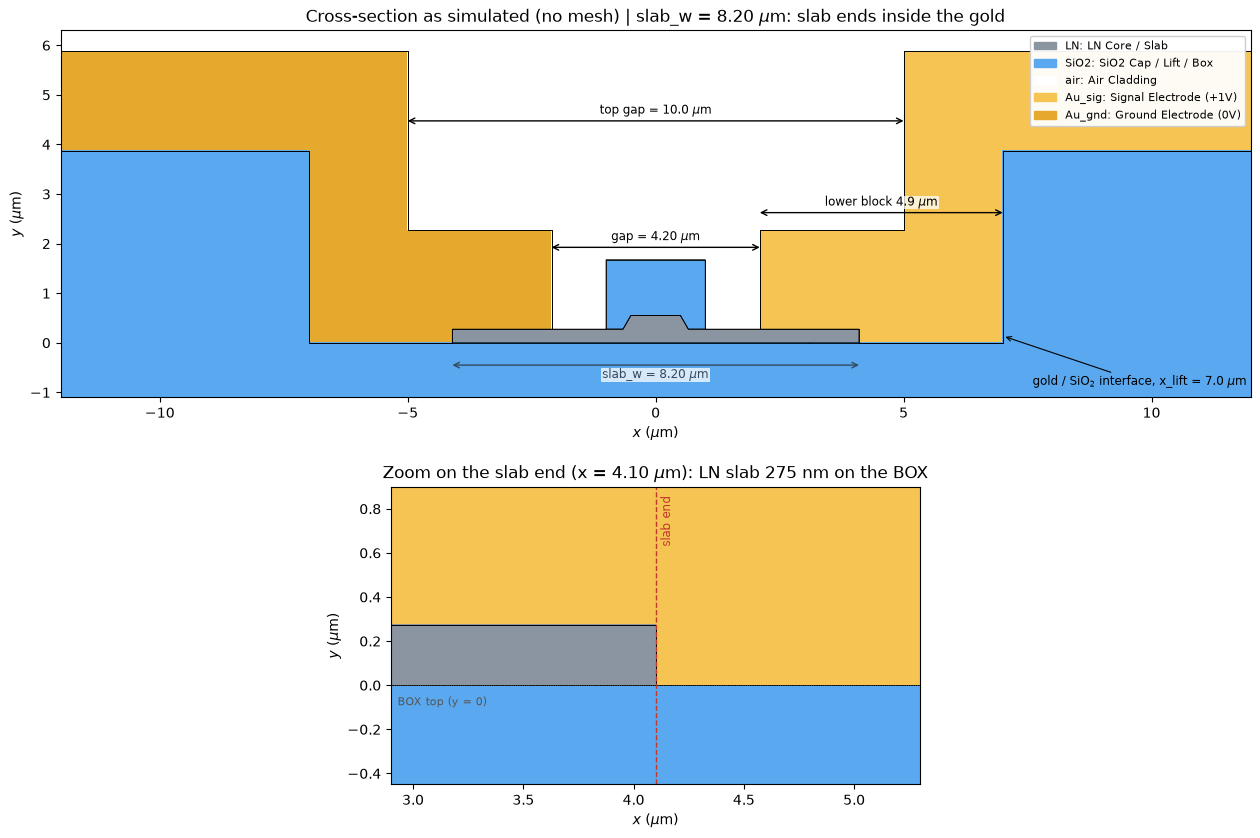

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


...

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


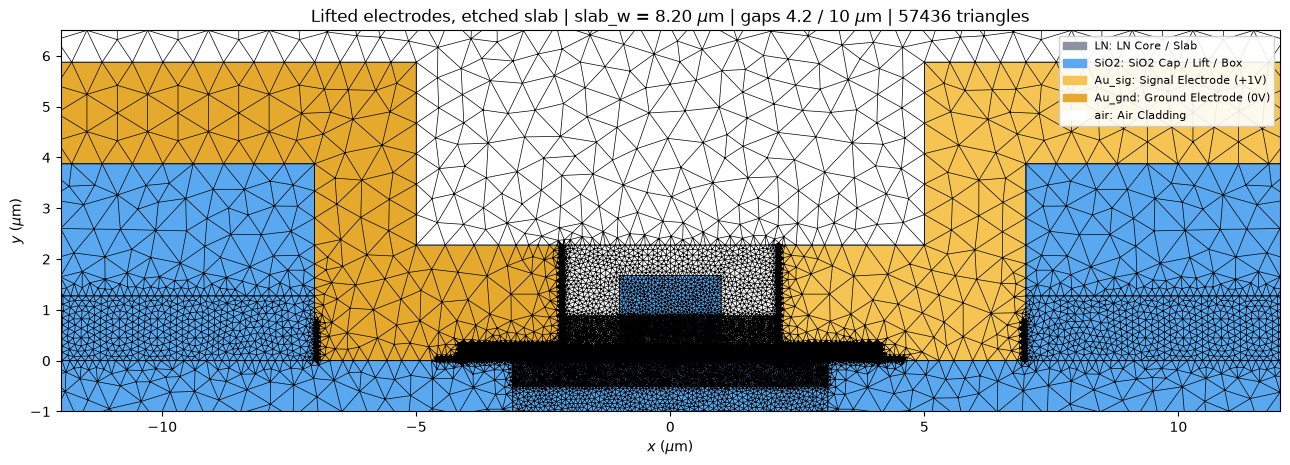

In [1]:
# %% [0] Geometry, Mesh & Material Configuration  --  LIFTED ELECTRODES, ETCHED LN SLAB
#
#   Same lifted-electrode cross-section as the "Lisbona lifted" design (bottom gap
#   4.2 um, top gap 10 um, 2.9 um overhang + 2.0 um column = 4.9 um lower block,
#   pad lifted on 3.6 um SiO2), but the LN slab is fully etched outside a width
#   SLAB_W centred on the rib.  The etched region (slab height) is filled by
#   whatever sits above it: air in the gap, gold under the lower blocks, SiO2
#   under the lifted pads.  All top surfaces keep their heights.
#
#   Three regimes, set by the slab edge x_s = SLAB_W / 2:
#     x_s <  GAP_BOT/2               slab ends in the air gap (narrower than the gap)
#     GAP_BOT/2 < x_s < x_lift       slab ends INSIDE the gold lower block
#     x_s >= x_lift                  slab runs past the gold / SiO2 interface
#   x_lift = GAP_TOP/2 + COL_W = 7.0 um is the outer edge of the lower block.
import warnings
from collections import OrderedDict
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from shapely.affinity import scale as _scale
from shapely.geometry import Polygon, MultiPolygon, GeometryCollection, box
from shapely.ops import unary_union
from skfem import MeshTri
from femwell.mesh import mesh_from_OrderedDict

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# femwell bug fix.  mesh_from_OrderedDict() tries to switch off gmsh's
# "extend mesh size from boundary" with `gmsh.model.mesh.MeshSizeExtendFromBoundary = 0`,
# which only sets a Python attribute: the gmsh option is never changed.  This
# wrapper applies the options femwell intended, so the mesh follows `resolutions`.
import gmsh
if not getattr(gmsh.model.mesh.field, "_size_fix", False):
    _orig_set_bg = gmsh.model.mesh.field.setAsBackgroundMesh

    def _set_bg_fixed(tag):
        _orig_set_bg(tag)
        gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

    gmsh.model.mesh.field.setAsBackgroundMesh = _set_bg_fixed
    gmsh.model.mesh.field._size_fix = True

# ============================================================
# 1. FIXED PHYSICAL & GEOMETRIC PARAMETERS
# ============================================================
wl = 1.575          # um
wl_m = wl * 1e-6
k0 = 2.0 * np.pi / wl               # 1/um
k0_m = k0 * 1e6                     # 1/m
L_cm = 1.0          # cm
V_bias = 1.0        # V
r33 = 30.8e-12      # m/V
n_guess = 1.8755
num_modes_search = 8

# ---- Vertical Dimensions (um) ------------------------------------------------
BOX_H = 4.7
TECN = 0.550                        # LN film thickness
WG_H = 0.275                        # rib height (etch depth)
SLAB_H = TECN - WG_H                # 0.275 um (LN slab thickness)
EL_H = 2.000                        # electrode thickness (lower block AND lifted pad)
BUFFER_H = 3.600                    # SiO2 under the lifted pad, measured from the slab top
CAP_H = 1.400                       # SiO2 cap on the rib, measured from the slab top
CLAD_ABOVE = 2.000                  # air kept above the top of the electrodes

# ---- Horizontal Dimensions (um) ---------------------------------------------
WG_TOP = 1.0
ALPHA = 60.0
GAP_BOT = 4.2                       # gap between the lower blocks
GAP_TOP = 10.0                      # gap between the columns (x_lift = GAP_TOP/2 + COL_W)
COL_W = 2.0                         # column (riser) width
CAP_W = 2.0                         # SiO2 cap width
EL_W = 30.0                         # total electrode width, from the gap edge outward
MARGIN = 5.0
SLAB_W = 8.2                        # total width of the LN slab left after the full etch
SLAB_RES = 0.0                      # LN left outside slab_w (partial second etch); 0 = full etch
SPACER_W = 0.0                      # SiO2 spacer between the slab end and the gold (0 = none);
                                    # only for a slab ending inside the gold, same height as the slab
GOLD_OUT = False                   # True: no SiO2 inside the electrodes: lower block, column and pad
                                    # fuse into one solid gold body out to the pad end (Cordoba-like
                                    # stepped electrode, no gold/SiO2 edge on the slab); air outside

basetta = WG_H / np.tan(np.deg2rad(ALPHA))
WG_BOTTOM = WG_TOP + 2.0 * basetta
OVERHANG = (GAP_TOP - GAP_BOT) / 2.0        # 2.9 um: lower block beyond the column
LOW_W = OVERHANG + COL_W                    # 4.9 um: lower-block width
X_LIFT = GAP_TOP / 2.0 + COL_W              # 7.0 um: gold / SiO2 interface
X_LOW_OUT = GAP_BOT / 2.0 + EL_W if GOLD_OUT else X_LIFT   # outer edge of the gold at slab level
SLAB_EXT = (SLAB_W - GAP_BOT) / 2.0         # slab edge beyond the gap edge (per side)
assert CAP_W > WG_BOTTOM, "cap must be wider than the rib base"
assert GAP_BOT > CAP_W, "cap must fit inside the bottom gap"
assert SLAB_W > CAP_W, "the cap must sit on the slab"
assert 0.0 <= SLAB_RES < SLAB_H and (SLAB_RES == 0.0 or SPACER_W == 0.0), "residual slab: 0 <= t < SLAB_H, no spacer"
assert SPACER_W == 0.0 or GAP_BOT < SLAB_W < GAP_TOP + 2 * COL_W - 2 * SPACER_W, (
    "the SiO2 spacer needs a slab that ends inside the gold")
assert OVERHANG > 0 and EL_W > LOW_W, "inconsistent electrode dimensions"
assert not GOLD_OUT or SLAB_W / 2.0 < X_LOW_OUT - 1.0, "GOLD_OUT: the slab must end inside the gold"

# ---- Material dispersion: every optical constant is computed at `wl` ---------
def n_LN(lam):
    """Congruent LiNbO3, Zelmon et al., JOSA B 14, 3319 (1997).  Returns (ne, no)."""
    l2 = lam ** 2
    ne_ = np.sqrt(1 + 2.9804 * l2 / (l2 - 0.02047) + 0.5981 * l2 / (l2 - 0.0666)
                  + 8.9543 * l2 / (l2 - 416.08))
    no_ = np.sqrt(1 + 2.6734 * l2 / (l2 - 0.01764) + 1.2290 * l2 / (l2 - 0.05914)
                  + 12.614 * l2 / (l2 - 474.6))
    return ne_, no_


def n_SiO2(lam):
    """Fused silica, Malitson, JOSA 55, 1205 (1965)."""
    l2 = lam ** 2
    return np.sqrt(1 + 0.6961663 * l2 / (l2 - 0.0684043 ** 2)
                   + 0.4079426 * l2 / (l2 - 0.1162414 ** 2)
                   + 0.8974794 * l2 / (l2 - 9.896161 ** 2))


# Gold has no Sellmeier form (free-electron metal).  Johnson & Christy, PRB 6,
# 4370 (1972), (lambda um, n, k); eps = (n - i k)^2 is interpolated linearly in
# photon energy, where it is smooth (Drude-like).  Sign convention exp(+jwt):
# Im(eps) < 0 is loss.
_AU_JC = np.array([
    (0.617, 0.21, 3.272), (0.659, 0.14, 3.697), (0.705, 0.13, 4.103),
    (0.756, 0.14, 4.542), (0.821, 0.16, 5.083), (0.892, 0.17, 5.663),
    (0.984, 0.22, 6.350), (1.088, 0.27, 7.150), (1.216, 0.35, 8.145),
    (1.393, 0.43, 9.519), (1.610, 0.56, 11.210), (1.937, 0.92, 13.780)])


def eps_Au_JC(lam):
    lam_t, n_t, k_t = _AU_JC.T
    assert lam_t.min() <= lam <= lam_t.max(), "wavelength outside the J&C table"
    E_t = 1.239842 / lam_t                      # eV, decreasing
    eps_t = (n_t - 1j * k_t) ** 2
    E = 1.239842 / lam
    return complex(np.interp(E, E_t[::-1], eps_t.real[::-1]),
                   np.interp(E, E_t[::-1], eps_t.imag[::-1]))


ne, no = n_LN(wl)
n_sio2 = n_SiO2(wl)
eps_au = eps_Au_JC(wl)
print(f"[materials @ {wl*1e3:.0f} nm] LN ne={ne:.6f} no={no:.6f} | "
      f"SiO2 n={n_sio2:.6f} | Au eps={eps_au.real:.2f}{eps_au.imag:+.2f}j")

# ---- Mesh scales (same as the converged lifted design) ------------------------
h_core = 0.040
h_skin = 0.012                      # gold on LN: the SPP decays into Au in ~22 nm
SKIN_T = 0.070                      # gold shell resolving the ~23 nm optical skin depth
BOT_SKIN_L = 0.5                    # shell on gold-on-BOX beyond an etched slab end
OUTER_WALL_SKIN_H = 0.5
# Corners where metal meets the LN slab carry a field singularity: every such
# corner gets a small square patch of very fine mesh, split by material.
CORNER_R = 0.050                    # corner patch half-size (um)
h_corner = 0.006                    # mesh size inside the corner patches (um)

MATERIALS = {
    "LN":     {"color": "#8b95a1", "eps_dc": (28.0, 44.0), "eps_opt": (ne**2, no**2, no**2), "desc": "LN Core / Slab"},
    "SiO2":   {"color": "#5aa9f0", "eps_dc": (3.75, 3.75), "eps_opt": (n_sio2**2, n_sio2**2, n_sio2**2), "desc": "SiO2 Cap / Lift / Box"},
    "air":    {"color": "#ffffff", "eps_dc": (1.00, 1.00), "eps_opt": (1.00, 1.00, 1.00), "desc": "Air Cladding"},
    "Au_sig": {"color": "#f6c453", "eps_dc": (1.00, 1.00), "eps_opt": (eps_au, eps_au, eps_au), "desc": "Signal Electrode (+1V)"},
    "Au_gnd": {"color": "#e5a92e", "eps_dc": (1.00, 1.00), "eps_opt": (eps_au, eps_au, eps_au), "desc": "Ground Electrode (0V)"},
}

PREFIX_TO_MAT = [
    ("core", "LN"), ("cap", "SiO2"), ("buf", "SiO2"),
    ("slab", "LN"), ("box", "SiO2"), ("clad", "air"),
    ("elR", "Au_sig"), ("elL", "Au_gnd"),
]

def material_of(region_name):
    base = region_name.split("___")[0]
    for prefix, mat in PREFIX_TO_MAT:
        if base.startswith(prefix):
            return mat
    raise KeyError(f"Unknown material for region: {region_name}")

def mirror(p):
    return _scale(p, xfact=-1.0, yfact=1.0, origin=(0, 0))

def _areal(g, tol=1e-10):
    """Keep only the polygonal part of a shapely result (drops touching lines/points)."""
    if g.is_empty:
        return Polygon()
    if isinstance(g, Polygon):
        return g if g.area > tol else Polygon()
    parts = [p for p in getattr(g, "geoms", []) if isinstance(p, (Polygon, MultiPolygon))]
    parts = [q for p in parts for q in (p.geoms if isinstance(p, MultiPolygon) else [p])
             if q.area > tol]
    if not parts:
        return Polygon()
    return parts[0] if len(parts) == 1 else MultiPolygon(parts)

# ============================================================
# 2. GEOMETRY GENERATOR
# ============================================================
def build_polygons():
    xg = GAP_BOT / 2.0                              # 2.10 um  lower-block inner edge
    x_col_in = GAP_TOP / 2.0                        # 5.00 um  column inner edge
    x_col_out = X_LIFT                              # 7.00 um  column outer edge (lift starts)
    x_low_out = X_LOW_OUT                           # gold outer edge at slab level (= x_col_out
                                                    # unless GOLD_OUT)
    xs = SLAB_W / 2.0                               # slab edge
    x_el_outer = xg + EL_W                          # 32.10 um end of the lifted pad
    DEV_W = 2.0 * x_el_outer + 2.0 * MARGIN         # 74.20 um
    x_dev_max = DEV_W / 2.0
    x_near = min(max(x_col_out, xs) + 15.0, x_dev_max - 2.0)
    x_fine = max(x_col_out, xs) + 1.0               # end of the finely meshed slab

    y_slab_top = SLAB_H                             # 0.275 (BOX top at y = 0)
    y_low_top = y_slab_top + EL_H                   # 2.275  top of the lower block
    y_buf_top = y_slab_top + BUFFER_H               # 3.875  pad bottom
    y_el_top = y_buf_top + EL_H                     # 5.875
    y_cap_top = y_slab_top + CAP_H                  # 1.675
    y_clad_top = y_el_top + CLAD_ABOVE              # 7.875
    y_fine_top = y_slab_top + 0.6                   # above this the mode is < -25 dB

    # corners: two patches must not overlap (they may coincide), so the patch
    # shrinks when the slab edge is within 2.5*CORNER_R of a gold edge
    w_sp = SPACER_W
    x_m = xs + w_sp                                 # where the gold starts beyond the slab
    r_c = CORNER_R
    for _p, _a in [(xs, xg), (x_m, x_low_out)] + ([(xs, x_m)] if w_sp > 0 else []):
        if abs(_p - _a) > 1e-9:
            r_c = min(r_c, abs(_p - _a) / 2.5)    # patches never touch
    assert r_c >= 0.01, f"slab edge {xs:.3f} um within 20 nm of a gold edge: not meshable"

    # ---- 1. LN: rib core and the (etched) slab ------------------------------
    core_poly = Polygon([
        (-WG_BOTTOM / 2.0, y_slab_top), (-WG_TOP / 2.0, y_slab_top + WG_H),
        (WG_TOP / 2.0, y_slab_top + WG_H), (WG_BOTTOM / 2.0, y_slab_top)])
    t_r = SLAB_RES                                  # residual LN outside slab_w
    slab = box(-xs, 0.0, xs, y_slab_top)
    if t_r > 0:
        slab = unary_union([slab, box(-x_dev_max, 0.0, x_dev_max, t_r)])

    # ---- 2. SiO2 cap (2.0 x 1.4 um, on the slab) -----------------------------
    cap_poly = box(-CAP_W / 2.0, y_slab_top, CAP_W / 2.0, y_fine_top).difference(core_poly)
    cap_up = box(-CAP_W / 2.0, y_fine_top, CAP_W / 2.0, y_cap_top)

    # ---- 3. Electrode (right = signal): the lower block reaches down to the
    #         BOX wherever the slab has been etched away.
    spacer_r = box(xs, 0.0, x_m, y_slab_top) if w_sp > 0 else Polygon()
    low_r = box(xg, 0.0, x_low_out, y_low_top).difference(slab).difference(spacer_r)
    col_r = box(x_col_in, y_low_top, x_col_out, y_el_top)
    pad_r = box(x_col_out, y_buf_top, x_el_outer, y_el_top)
    if GOLD_OUT:                                    # former lift filled with gold
        pad_r = box(x_col_in, y_low_top, x_el_outer, y_el_top)
    el_r = unary_union([low_r, col_r, pad_r])
    assert el_r.geom_type == "Polygon", "electrode blocks do not fuse into one body"

    # ---- 4. SiO2 under the lifted pad, down to the BOX where the slab is gone
    buf_r = (Polygon() if GOLD_OUT else
             box(x_col_out, 0.0, x_dev_max, y_buf_top).difference(slab).difference(low_r))
    buf_near_r = _areal(buf_r.intersection(box(x_col_out, 0.0, x_near, y_slab_top + 1.0)))
    buf_far_r = _areal(buf_r.difference(box(x_col_out, 0.0, x_near, y_slab_top + 1.0)))

    # ---- 5. BOX (fine only in the top 0.5 um near the rib) -------------------
    box_near = box(-(xg + 1.0), -0.5, xg + 1.0, 0.0)
    box_mid = box(-(xg + 1.0), -1.5, xg + 1.0, -0.5)
    box_far = box(-x_dev_max, -BOX_H, x_dev_max, 0.0).difference(
        box(-(xg + 1.0), -1.5, xg + 1.0, 0.0))

    # ---- 6. Air: everything left above the BOX -------------------------------
    solids = unary_union([core_poly, slab, cap_poly, cap_up, el_r, mirror(el_r),
                          buf_r, mirror(buf_r), spacer_r, mirror(spacer_r)])
    clad_all = box(-x_dev_max, 0.0, x_dev_max, y_clad_top).difference(solids)
    clad_gap = _areal(clad_all.intersection(box(-xg, 0.0, xg, y_fine_top)))
    clad_gap_up = _areal(clad_all.intersection(box(-xg, y_fine_top, xg, y_cap_top + 0.6)))
    clad_far = _areal(clad_all.difference(box(-xg, 0.0, xg, y_cap_top + 0.6)))

    base = OrderedDict()
    base["core"] = core_poly
    base["cap"] = cap_poly
    base["cap_up"] = cap_up
    base["elR_bulk"] = el_r
    base["elL_bulk"] = mirror(el_r)
    base["buf_near_r"] = buf_near_r
    base["buf_near_l"] = mirror(buf_near_r)
    base["buf_far_r"] = buf_far_r
    base["buf_far_l"] = mirror(buf_far_r)
    if w_sp > 0:
        base["buf_spacer_r"] = spacer_r
        base["buf_spacer_l"] = mirror(spacer_r)
    base["slab_fine"] = _areal(slab.intersection(box(-x_fine, 0.0, x_fine, y_slab_top)))
    base["slab_mid"] = _areal(slab.intersection(box(-x_near, 0.0, x_near, y_slab_top))
                              .difference(box(-x_fine, 0.0, x_fine, y_slab_top)))
    base["slab_far"] = _areal(slab.difference(box(-x_near, 0.0, x_near, y_slab_top)))
    base["box_near"] = box_near
    base["box_mid"] = box_mid
    base["box_far"] = box_far
    base["clad_gap"] = clad_gap
    base["clad_gap_up"] = clad_gap_up
    base["clad_far"] = clad_far

    # ---- 7. Refinement zones -------------------------------------------------
    # 7a. corner patches: every corner where gold touches the LN slab, plus the
    #     gold foot in the gap if the slab stops short of the gold.
    pts = []
    if t_r > 0:                                      # partial etch: gold always sits on LN
        if xs < xg - 1e-9:
            pts.append((xg, t_r))                    # gold foot on the residual slab
        else:
            pts.append((xg, y_slab_top))
            if xs < x_low_out - 1e-9:
                pts.append((xs, t_r))                # thickness step under the gold
        if xs < x_low_out - 1e-9:
            pts.append((x_low_out, t_r))             # outer corner on the residual slab
        else:
            pts.append((x_low_out, y_slab_top))
    elif xs > xg - 1e-9:
        pts.append((xg, y_slab_top))                 # inner corner: gold / LN / air
    if t_r == 0 and xs < xg + 1e-9:
        pts.append((xg, 0.0))                        # gold foot on the BOX (slab_w <= gap)
    if t_r > 0:
        pass
    elif xg + 1e-9 < xs < x_low_out - 1e-9 and w_sp > 0:
        pts += [(xs, y_slab_top),                    # slab end under the gold, on the spacer
                (x_m, y_slab_top), (x_m, 0.0)]       # spacer wrapped by gold
    elif xg + 1e-9 < xs < x_low_out - 1e-9:
        pts += [(xs, y_slab_top), (xs, 0.0)]         # slab end wrapped by gold
    elif t_r == 0 and xs >= x_low_out - 1e-9:
        pts.append((x_low_out, y_slab_top))          # outer corner: gold / LN / SiO2
    patches_r = unary_union([box(px - r_c, py - r_c, px + r_c, py + r_c)
                             for px, py in pts])
    patches = unary_union([patches_r, mirror(patches_r)])

    # 7b. gold skin: within SKIN_T of the LN slab, the inner wall (full height),
    #     the foot of the outer wall, and BOT_SKIN_L of gold-on-BOX beyond an
    #     etched slab end.
    x_e = max(x_m, xg)
    skin_zone_r = unary_union([
        unary_union([slab, spacer_r]).buffer(SKIN_T, join_style=2),
        box(xg, 0.0, xg + SKIN_T, y_low_top),
        box(x_low_out - SKIN_T, 0.0, x_low_out, y_slab_top + OUTER_WALL_SKIN_H),
        box(x_e, 0.0, min(x_e + BOT_SKIN_L, x_low_out), SKIN_T) if x_e < x_low_out else Polygon(),
    ])
    skin_zone = unary_union([skin_zone_r, mirror(skin_zone_r)])

    polys = OrderedDict()
    for name, reg in base.items():
        if reg.is_empty:
            continue
        pc = _areal(reg.intersection(patches))
        if not pc.is_empty:
            polys[name + "_corner"] = pc
        reg = _areal(reg.difference(patches))
        if name.startswith("el"):
            sk = _areal(reg.intersection(skin_zone))
            polys[name.replace("bulk", "skin")] = sk
            reg = _areal(reg.difference(skin_zone))
        if not reg.is_empty:
            polys[name] = reg

    return polys, DEV_W, y_clad_top

# ============================================================
# 3. MESH GENERATION & RESOLUTION SETUP
# ============================================================
polygons, DEV_W, Y_TOP = build_polygons()

_base_res = {
    "core":        (h_core, 0.30),
    "cap":         (0.035, 0.30),
    "cap_up":      (0.080, 0.30),
    "clad_gap":    (0.040, 0.30),
    "clad_gap_up": (0.100, 0.30),
    "slab_fine":   (0.025, 0.30),
    "slab_mid":    (0.110, 0.40),
    "slab_far":    (0.150, 0.50),
    "box_near":    (0.040, 0.30),
    "box_mid":     (0.100, 0.30),
    "box_far":     (0.800, 1.00),
    "buf_near_r":  (0.150, 0.40),
    "buf_near_l":  (0.150, 0.40),
    "buf_far_r":   (0.800, 1.00),
    "buf_far_l":   (0.800, 1.00),
    "buf_spacer_r": (0.020, 0.20),
    "buf_spacer_l": (0.020, 0.20),
    "elR_bulk":    (0.800, 0.50),
    "elL_bulk":    (0.800, 0.50),
    "elR_skin":    (h_skin, 0.20),
    "elL_skin":    (h_skin, 0.20),
    "clad_far":    (0.800, 1.00),
}
resolutions = {}
for _k in polygons:
    if _k.endswith("_corner"):
        resolutions[_k] = {"resolution": h_corner, "distance": 0.10}
    else:
        _r, _d = _base_res[_k]
        resolutions[_k] = {"resolution": _r, "distance": _d}

# ---- Validity / consistency assertions ---------------------------------------
_names = list(polygons)
for _n, _p in polygons.items():
    assert _p.is_valid and not _p.is_empty and _p.area > 1e-12, f"degenerate region {_n}"
for _i in range(len(_names)):
    for _j in range(_i + 1, len(_names)):
        _ov = polygons[_names[_i]].intersection(polygons[_names[_j]]).area
        assert _ov < 1e-10, f"overlap {_names[_i]} & {_names[_j]}: {_ov:.2e}"
_tot = sum(p.area for p in polygons.values())
assert abs(_tot - DEV_W * (BOX_H + Y_TOP)) < 1e-8, "tiling gap"

_regime = ("slab ends in the air gap" if SLAB_EXT < -1e-9 else
           "slab ends at the gold inner edge" if abs(SLAB_EXT) < 1e-9 else
           "slab ends inside the gold" if SLAB_W / 2 < X_LOW_OUT - 1e-9 else
           "slab ends at the gold/SiO2 interface" if abs(SLAB_W / 2 - X_LIFT) < 1e-9 else
           "slab runs past the gold/SiO2 interface")
print(f"[geometry OK] {len(polygons)} regions tile exactly")
print(f"              SLAB_W {SLAB_W:.2f} um (edge {SLAB_EXT:+.2f} um from the gap edge): {_regime}"
      + (f" | SiO2 spacer {SPACER_W*1e3:.0f} nm before the gold" if SPACER_W > 0 else "")
      + (f" | {SLAB_RES*1e3:.0f} nm LN left outside slab_w" if SLAB_RES > 0 else ""))
print(f"              gaps: bottom {GAP_BOT:.2f} um / top {GAP_TOP:.2f} um | "
      f"lower block {LOW_W:.2f} um | " + (f"solid gold electrode out to x = {X_LOW_OUT:.2f} um, "
      f"no SiO2 inside the electrode (no gold/SiO2 edge on the slab)" if GOLD_OUT else
      f"gold/SiO2 interface at x = {X_LIFT:.2f} um"))

raw_mesh = mesh_from_OrderedDict(
    polygons,
    resolutions=resolutions,
    default_resolution_min=0.5 * min(h_skin, h_corner),
    default_resolution_max=0.6,
)
skfem_mesh = MeshTri(raw_mesh.points[:, :2].T, raw_mesh.cells_dict["triangle"].T)
tri_subdomains = raw_mesh.cell_data_dict["gmsh:physical"]["triangle"]
name_to_id = {
    name: data[0] if hasattr(data, "__getitem__") else data
    for name, data in raw_mesh.field_data.items()
}

mat_of_el = np.empty(skfem_mesh.nelements, dtype=object)
for raw_name, s_id in name_to_id.items():
    if raw_name.split("___")[0] in polygons:
        mat_of_el[tri_subdomains == s_id] = material_of(raw_name)

assert not np.any(mat_of_el == None), (  # noqa: E711
    f"{int(np.sum(mat_of_el == None))} unassigned elements")  # noqa: E711
print(f"[mesh OK] {skfem_mesh.nelements} triangles, {skfem_mesh.nvertices} vertices")

# ---- Cross-section WITHOUT the mesh ------------------------------------------
# Every triangle is filled with the colour of the material the SOLVER assigns to
# it (mat_of_el), so this is what is simulated, not just what was drawn.  Thin
# black lines are the material boundaries.
from matplotlib.colors import ListedColormap

_mkeys = list(MATERIALS)
_midx = np.array([_mkeys.index(m) for m in mat_of_el], dtype=float)
_mcmap = ListedColormap([MATERIALS[m]["color"] for m in _mkeys])
_by_mat = {}
for _n, _p in polygons.items():
    _by_mat.setdefault(material_of(_n), []).append(_p)
_mat_shapes = {m: unary_union(v) for m, v in _by_mat.items()}


def _draw_materials(ax):
    ax.tripcolor(skfem_mesh.p[0], skfem_mesh.p[1], skfem_mesh.t.T, facecolors=_midx,
                 cmap=_mcmap, vmin=-0.5, vmax=len(_mkeys) - 0.5,
                 edgecolors="face", linewidth=0.0, antialiased=False)
    for _shape in _mat_shapes.values():
        for _part in (_shape.geoms if hasattr(_shape, "geoms") else [_shape]):
            for _ring in [_part.exterior, *_part.interiors]:
                _xy = np.asarray(_ring.coords)
                ax.plot(_xy[:, 0], _xy[:, 1], color="k", lw=0.6)


def _dim(ax, x0, x1, y, label, color="k", above=True):
    ax.annotate("", (x0, y), (x1, y),
                arrowprops=dict(arrowstyle="<->", color=color, lw=1.0, shrinkA=0, shrinkB=0))
    ax.text(0.5 * (x0 + x1), y + (0.08 if above else -0.08), label, color=color, fontsize=8.5,
            ha="center", va="bottom" if above else "top",
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.6))


_xs, _xg, _yst = SLAB_W / 2.0, GAP_BOT / 2.0, SLAB_H
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(13, 8.6), gridspec_kw=dict(height_ratios=[1.45, 1]))
_draw_materials(ax_a)
_xl = max(12.0, _xs + 2.0)
_dim(ax_a, -_xs, _xs, -0.45, rf"slab_w = {SLAB_W:.2f} $\mu$m", color="#34495e", above=False)
_dim(ax_a, -_xg, _xg, _yst + EL_H - 0.35, rf"gap = {GAP_BOT:.2f} $\mu$m")
_dim(ax_a, -GAP_TOP / 2.0, GAP_TOP / 2.0, _yst + BUFFER_H + 0.6, rf"top gap = {GAP_TOP:.1f} $\mu$m")
if not GOLD_OUT:
    _dim(ax_a, _xg, X_LIFT, _yst + EL_H + 0.35, rf"lower block {LOW_W:.1f} $\mu$m")
ax_a.annotate(rf"no SiO$_2$ in the electrode: solid gold out to x = {X_LOW_OUT:.1f} $\mu$m" if GOLD_OUT else
              rf"gold / SiO$_2$ interface, x_lift = {X_LIFT:.1f} $\mu$m", (X_LIFT, _yst / 2 if not GOLD_OUT else _yst + EL_H),
              (X_LIFT + 0.6, -0.85), fontsize=8.5, arrowprops=dict(arrowstyle="->", lw=0.8))
ax_a.legend(handles=[mpatches.Patch(color=MATERIALS[m]["color"], label=f"{m}: {MATERIALS[m]['desc']}")
                     for m in _mkeys if m in _mat_shapes],
            loc="upper right", framealpha=0.95, fontsize=8)
ax_a.set_xlim(-_xl, _xl); ax_a.set_ylim(-1.1, 6.3); ax_a.set_aspect("equal")
ax_a.set_xlabel(r"$x$ ($\mu$m)"); ax_a.set_ylabel(r"$y$ ($\mu$m)")
ax_a.set_title(rf"Cross-section as simulated (no mesh) | slab_w = {SLAB_W:.2f} $\mu$m: {_regime}")

# zoom on the right-hand slab end: what surrounds the end of the LN slab
_draw_materials(ax_b)
_zx0, _zx1 = _xs - 1.2, _xs + 1.2
for _xv, _lab, _c in [(_xg, "gold inner edge", "#b9770e"), (X_LOW_OUT, "gold / SiO$_2$ interface", "#1f618d"),
                      (_xs, "slab end", "#c0392b")]:
    if _zx0 < _xv < _zx1:
        ax_b.axvline(_xv, color=_c, ls="--", lw=1.0)
        ax_b.text(_xv + 0.02, 0.86, _lab, color=_c, fontsize=8.5, rotation=90, va="top")
ax_b.axhline(0.0, color="#555", lw=0.6, ls=":")
ax_b.text(_zx0 + 0.03, -0.05, "BOX top (y = 0)", fontsize=8, va="top", color="#555")
ax_b.set_xlim(_zx0, _zx1); ax_b.set_ylim(-0.45, 0.9); ax_b.set_aspect("equal")
ax_b.set_xlabel(r"$x$ ($\mu$m)"); ax_b.set_ylabel(r"$y$ ($\mu$m)")
ax_b.set_title(rf"Zoom on the slab end (x = {_xs:.2f} $\mu$m): LN slab {SLAB_H*1e3:.0f} nm on the BOX")
plt.tight_layout()
plt.show()

# ---- Cross-section visualization ---------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4.8))
legend_patches = []
seen = set()

for raw_name, s_id in name_to_id.items():
    if raw_name.split("___")[0] not in polygons:
        continue
    mat_key = material_of(raw_name)
    col = MATERIALS[mat_key]["color"]
    elem_idx = np.where(tri_subdomains == s_id)[0]
    if elem_idx.size == 0:
        continue
    sub_mesh = MeshTri(skfem_mesh.p, skfem_mesh.t[:, elem_idx])
    sub_mesh.plot(np.zeros(sub_mesh.nelements), ax=ax, shading="flat",
                  cmap=plt.matplotlib.colors.ListedColormap([col]))
    sub_mesh.draw(ax=ax, color="black", lw=0.15)
    if mat_key not in seen:
        legend_patches.append(mpatches.Patch(color=col, label=f"{mat_key}: {MATERIALS[mat_key]['desc']}"))
        seen.add(mat_key)

ax.legend(handles=legend_patches, loc="upper right", framealpha=0.9, fontsize=8)
ax.set_title(rf"Lifted electrodes, etched slab | slab_w = {SLAB_W:.2f} $\mu$m | "
             rf"gaps {GAP_BOT:.1f} / {GAP_TOP:.0f} $\mu$m | {skfem_mesh.nelements} triangles")
ax.set_xlim([-max(12.0, SLAB_W / 2 + 2), max(12.0, SLAB_W / 2 + 2)])
ax.set_ylim([-1.0, 6.5])
ax.set_xlabel(r"$x$ ($\mu$m)")
ax.set_ylabel(r"$y$ ($\mu$m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

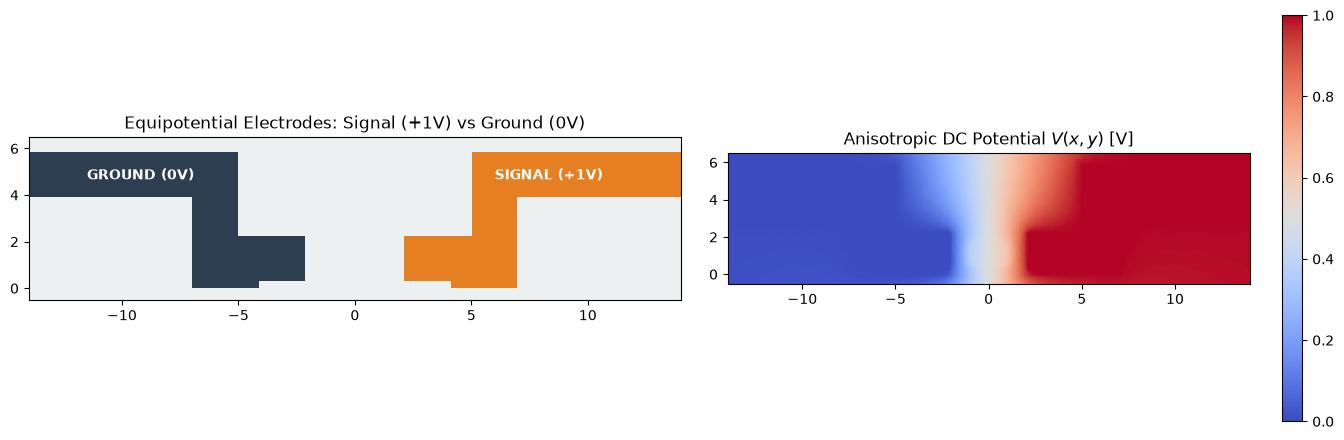

In [2]:
# %% [1] Anisotropic DC Electrostatics
from skfem import Basis, ElementTriP0, ElementTriP1, BilinearForm, asm, condense, solve
from skfem.helpers import grad

basis_dc = Basis(skfem_mesh, ElementTriP1(), intorder=4)
basis_p0 = Basis(skfem_mesh, ElementTriP0(), intorder=4)

eps_dc_x = np.array([MATERIALS[m]["eps_dc"][0] for m in mat_of_el], dtype=float)
eps_dc_y = np.array([MATERIALS[m]["eps_dc"][1] for m in mat_of_el], dtype=float)

@BilinearForm
def laplace_aniso(u, v, w):
    return w.eps_x * grad(u)[0] * grad(v)[0] + w.eps_y * grad(u)[1] * grad(v)[1]

K = asm(
    laplace_aniso,
    basis_dc,
    eps_x=basis_p0.interpolate(eps_dc_x),
    eps_y=basis_p0.interpolate(eps_dc_y),
)

sig_elements = np.where(mat_of_el == "Au_sig")[0]
gnd_elements = np.where(mat_of_el == "Au_gnd")[0]

dofs_signal = basis_dc.get_dofs(elements=sig_elements).all()
dofs_ground = basis_dc.get_dofs(elements=gnd_elements).all()
dofs_dirichlet = np.unique(np.concatenate([dofs_signal, dofs_ground]))

u_dirichlet = np.zeros(basis_dc.N)
u_dirichlet[dofs_signal] = V_bias
u_dirichlet[dofs_ground] = 0.0

K_c, f_c, u_c, I = condense(K, np.zeros(basis_dc.N), x=u_dirichlet, D=dofs_dirichlet)
potential_nodes = u_c.copy()
potential_nodes[I] = solve(K_c, f_c)

grad_V = basis_dc.interpolate(potential_nodes).grad
Ex_dc = -np.mean(grad_V[0], axis=-1) if grad_V.ndim == 3 else -grad_V[0]

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax0 = axes[0]
electrode_field = np.zeros(skfem_mesh.nelements)
electrode_field[mat_of_el == "Au_sig"] = 1.0
electrode_field[mat_of_el == "Au_gnd"] = -1.0

skfem_mesh.plot(electrode_field, ax=ax0, shading="flat", cmap=plt.matplotlib.colors.ListedColormap(["#2c3e50", "#ecf0f1", "#e67e22"]))
ax0.text(GAP_TOP / 2 + 1.0, SLAB_H + BUFFER_H + 0.8, "SIGNAL (+1V)", color="white", fontweight="bold")
ax0.text(-GAP_TOP / 2 - 6.5, SLAB_H + BUFFER_H + 0.8, "GROUND (0V)", color="white", fontweight="bold")
ax0.set_title("Equipotential Electrodes: Signal (+1V) vs Ground (0V)")
ax0.set_xlim([-14.0, 14.0])
ax0.set_ylim([-0.5, 6.5])
ax0.set_aspect("equal")

ax1 = axes[1]
skfem_mesh.plot(potential_nodes, ax=ax1, shading="gouraud", cmap="coolwarm", colorbar=True)
ax1.set_title(r"Anisotropic DC Potential $V(x, y)$ [V]")
ax1.set_xlim([-14.0, 14.0])
ax1.set_ylim([-0.5, 6.5])
ax1.set_aspect("equal")

plt.tight_layout()
plt.show()

In [3]:
# %% [2] Optical Eigensolver (N1 x P1 Elements)
import scipy.constants
from skfem import ElementTriN1, ElementTriP0, ElementTriP1, BilinearForm, solve, condense
from skfem.helpers import curl, dot, grad
from skfem.utils import solver_eigen_scipy
from femwell.maxwell.waveguide import Mode, Modes, calculate_hfield, calculate_overlap
from skfem import ElementTriN2, ElementTriP2 

def compute_modes_anisotropic(
    basis_epsilon_r,
    eps_xx,
    eps_yy,
    eps_zz,
    wavelength,
    num_modes=8,
    n_guess=1.8755,
):
    c0 = scipy.constants.speed_of_light
    k0_val = 2.0 * np.pi / wavelength
    element = ElementTriN1() * ElementTriP1()   
    basis = basis_epsilon_r.with_element(element)
    basis_eps = basis.with_element(basis_epsilon_r.elem)

    @BilinearForm(dtype=complex)
    def aform(e_t, e_z, v_t, v_z, w):
        return (
            curl(e_t) * curl(v_t) / k0_val**2
            - (w.eps_xx * e_t[0] * v_t[0] + w.eps_yy * e_t[1] * v_t[1])
            + dot(grad(e_z), v_t)
            + (w.eps_xx * e_t[0] * grad(v_z)[0] + w.eps_yy * e_t[1] * grad(v_z)[1])
            - w.eps_zz * e_z * v_z * k0_val**2
        )

    @BilinearForm(dtype=complex)
    def bform(e_t, e_z, v_t, v_z, w):
        return -dot(e_t, v_t) / k0_val**2

    A = aform.assemble(
        basis,
        eps_xx=basis_eps.interpolate(eps_xx),
        eps_yy=basis_eps.interpolate(eps_yy),
        eps_zz=basis_eps.interpolate(eps_zz),
    )
    B = bform.assemble(basis)

    bnd_dofs = basis.get_dofs(facets=skfem_mesh.boundary_facets())
    lams, xs = solve(
        *condense(-A, -B, D=bnd_dofs, x=basis.zeros(dtype=complex)),
        solver=solver_eigen_scipy(k=num_modes, sigma=k0_val**2 * n_guess**2),
    )

    xs[basis.split_indices()[1], :] /= 1j * np.sqrt(lams[np.newaxis, :] / k0_val**4)

    hs = []
    omega = k0_val * (c0 * 1e6)
    for i, lam in enumerate(lams):
        H = calculate_hfield(basis, xs[:, i], np.sqrt(lam), omega=omega)
        power = calculate_overlap(basis, xs[:, i], H, basis, xs[:, i], H)
        xs[:, i] /= np.sqrt(power)
        H /= np.sqrt(power)
        hs.append(H)

    return Modes(
        modes=[
            Mode(
                frequency=(c0 * 1e6) / wavelength,
                k=np.sqrt(lams[i]),
                basis_epsilon_r=basis_epsilon_r,
                epsilon_r=eps_xx,
                basis=basis,
                E=xs[:, i],
                H=hs[i],
            )
            for i in range(num_modes)
        ]
    )

eps_xx = np.array([MATERIALS[m]["eps_opt"][0] for m in mat_of_el], dtype=complex)
eps_yy = np.array([MATERIALS[m]["eps_opt"][1] for m in mat_of_el], dtype=complex)
eps_zz = np.array([MATERIALS[m]["eps_opt"][2] for m in mat_of_el], dtype=complex)

basis_epsilon_r = Basis(skfem_mesh, ElementTriP0(), intorder=4)

import time
t_eig0 = time.time()
modes = compute_modes_anisotropic(
    basis_epsilon_r,
    eps_xx,
    eps_yy,
    eps_zz,
    wavelength=wl,
    num_modes=num_modes_search,
    n_guess=n_guess,
)
print(f"Eigensolver complete in {time.time() - t_eig0:.1f}s: computed {len(modes)} optical modes around n_guess = {n_guess}.")

Eigensolver complete in 28.9s: computed 8 optical modes around n_guess = 1.8755.


Idx  | Re(neff)   | Im(neff)     | TE %     | Core Pwr % | Unipolarity 
----------------------------------------------------------------------------------


0    | 1.88403    | -6.42e-07    | 95.27  % | 36.68    % | 1.0000      


1    | 1.85367    | -7.81e-09    | 1.85   % | 31.72    % | 0.0014      
2    | 1.85051    | -1.10e-02    | 11.99  % | 0.00     % | 0.3996      


3    | 1.85049    | -1.10e-02    | 11.99  % | 0.00     % | 1.0000      


4    | 1.99127    | -1.06e-02    | 7.81   % | 0.00     % | 1.0000      
5    | 1.99126    | -1.06e-02    | 7.81   % | 0.00     % | 1.0000      


6    | 1.74411    | -3.85e-05    | 87.96  % | 16.32    % | 0.0000      


7    | 1.68521    | -2.52e-04    | 26.12  % | 19.22    % | 0.1463      


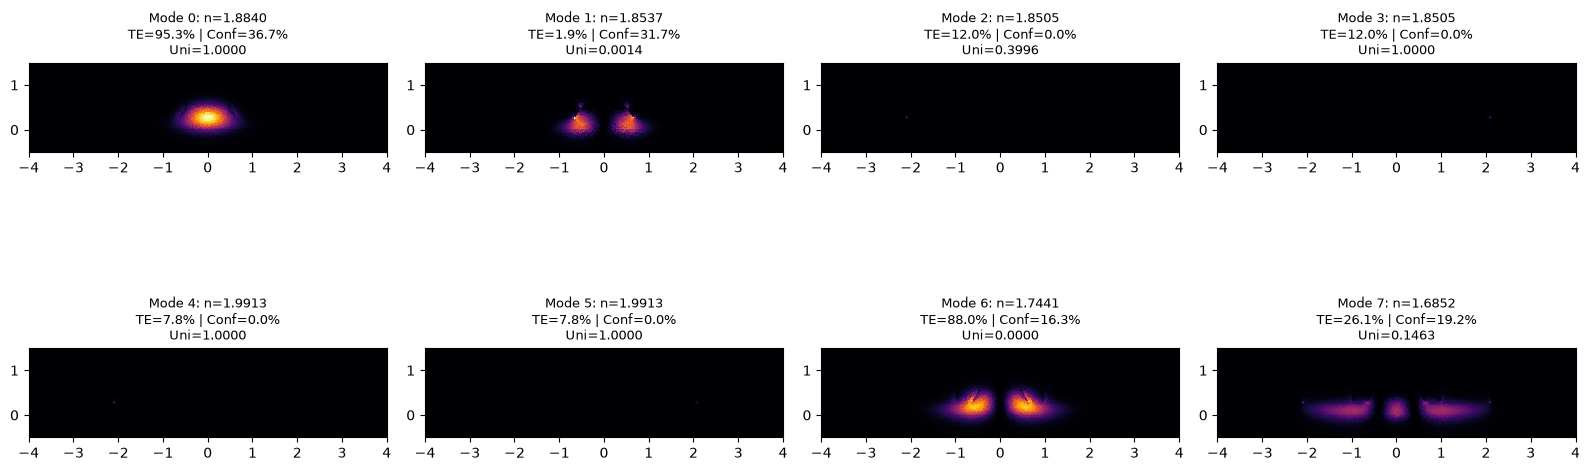

In [4]:
# %% [3] High-Precision Diagnostics & Mode Gallery
from skfem import Functional

core_ids = [s_id for name, s_id in name_to_id.items() if name.split("___")[0] == "core"]
is_core = np.zeros(skfem_mesh.nelements, dtype=float)
is_core[np.isin(tri_subdomains, core_ids)] = 1.0
is_core_field = basis_p0.interpolate(is_core)

@Functional(dtype=complex)
def _px(w):
    return np.abs(w["E"][0][0]) ** 2

@Functional(dtype=complex)
def _ptot(w):
    return (
        np.abs(w["E"][0][0]) ** 2
        + np.abs(w["E"][0][1]) ** 2
        + np.abs(w["E"][1]) ** 2
    )

@Functional(dtype=complex)
def _p_core(w):
    return w["is_core"] * (
        np.abs(w["E"][0][0]) ** 2
        + np.abs(w["E"][0][1]) ** 2
        + np.abs(w["E"][1]) ** 2
    )

@Functional(dtype=complex)
def _ex_core_signed(w):
    return w["is_core"] * np.real(w["E"][0][0])

@Functional(dtype=complex)
def _ex_core_abs(w):
    return w["is_core"] * np.abs(np.real(w["E"][0][0]))

mode_diagnostics = []

print("=" * 82)
print(f"{'Idx':<4} | {'Re(neff)':<10} | {'Im(neff)':<12} | {'TE %':<8} | {'Core Pwr %':<10} | {'Unipolarity':<12}")
print("-" * 82)

for idx, mode in enumerate(modes):
    E_interp = mode.basis.interpolate(mode.E)

    P_x = np.real(_px.assemble(mode.basis, E=E_interp))
    P_tot = np.real(_ptot.assemble(mode.basis, E=E_interp))
    P_core = np.real(_p_core.assemble(mode.basis, E=E_interp, is_core=is_core_field))

    te_ratio = P_x / P_tot
    core_confinement = P_core / P_tot

    signed = np.real(_ex_core_signed.assemble(mode.basis, E=E_interp, is_core=is_core_field))
    absval = np.real(_ex_core_abs.assemble(mode.basis, E=E_interp, is_core=is_core_field))

    unipolarity = 0.0000 if absval < 1e-12 else np.abs(signed) / absval

    neff_val = complex(mode.k / k0)

    mode_diagnostics.append({
        "index": idx,
        "mode": mode,
        "neff": neff_val,
        "te_ratio": te_ratio,
        "core_conf": core_confinement,
        "unipolarity": unipolarity,
    })

    print(
        f"{idx:<4} | "
        f"{neff_val.real:<10.5f} | "
        f"{neff_val.imag:<12.2e} | "
        f"{te_ratio * 100:<7.2f}% | "
        f"{core_confinement * 100:<9.2f}% | "
        f"{unipolarity:<12.4f}"
    )

print("=" * 82)

# Full Mode Gallery Plot
cols = 4
rows = int(np.ceil(len(modes) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.4 * rows))
axes = np.array(axes).flatten()

for idx, diag in enumerate(mode_diagnostics):
    ax = axes[idx]
    E_interp = diag["mode"].basis.interpolate(diag["mode"].E)
    Ex_elem = np.mean(np.abs(E_interp[0].value[0]) ** 2, axis=-1)

    skfem_mesh.plot(Ex_elem, ax=ax, shading="flat", cmap="inferno")
    title_str = (
        f"Mode {idx}: n={diag['neff'].real:.4f}\n"
        f"TE={diag['te_ratio']*100:.1f}% | Conf={diag['core_conf']*100:.1f}%\n"
        f"Uni={diag['unipolarity']:.4f}"
    )
    ax.set_title(title_str, fontsize=9)
    ax.set_xlim([-4.0, 4.0])
    ax.set_ylim([-0.5, 1.5])
    ax.set_aspect("equal")

for j in range(len(modes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
# %% [4] Overlap Integral, Vpi*L & Optical Attenuation
from skfem import Functional

# Fundamental TE mode identification
guided_cands = [
    d for d in mode_diagnostics
    if d["te_ratio"] >= 0.75 and d["core_conf"] >= 0.20 and d["unipolarity"] >= 0.85
]

if not guided_cands:
    raise RuntimeError("Fundamental TE rib mode not found. Check n_guess or eigensolver outputs.")

guided_cands.sort(key=lambda x: x["neff"].real, reverse=True)
fund_diag = guided_cands[0]
chosen_idx = fund_diag["index"]
fund_mode = fund_diag["mode"]
n_eff = fund_diag["neff"]

# 1. Optical Attenuation (Ohmic Metal Loss matching COMSOL Att_Opt)
att_opt_dB_m = np.abs(20.0 * np.log10(np.e) * k0_m * np.imag(n_eff))
att_opt_dB_cm = att_opt_dB_m / 100.0

# 2. Electro-Optic Overlap Integral (Gamma)
ln_mask = (mat_of_el == "LN")
Ex_dc_ln = np.zeros(skfem_mesh.nelements, dtype=float)
Ex_dc_ln[ln_mask] = Ex_dc[ln_mask]
Ex_dc_ln_field = basis_p0.interpolate(Ex_dc_ln)

E_fund_interp = fund_mode.basis.interpolate(fund_mode.E)

@Functional(dtype=complex)
def _num(w): 
    return w["Ex_dc_ln"] * np.abs(w["E"][0][0]) ** 2

@Functional(dtype=complex)
def _den(w): 
    return np.abs(w["E"][0][0]) ** 2

num = np.real(_num.assemble(fund_mode.basis, E=E_fund_interp, Ex_dc_ln=Ex_dc_ln_field))
den = np.real(_den.assemble(fund_mode.basis, E=E_fund_interp))

# Replace GAP with GAP_BOT
overlap = (GAP_BOT / V_bias) * (num / den)
Vpi_L_m = (GAP_BOT * 1e-6 * wl_m) / (r33 * np.abs(overlap) * (ne**3) * 2.0)
Vpi_L_Vcm = Vpi_L_m * 100.0
Vpi = Vpi_L_Vcm / L_cm

# 3. Formatted Simulation Summary
print("=" * 55)
print("             ELECTRO-OPTIC SIMULATION RESULTS")
print("=" * 55)
print(f"Selected Mode Index:         {chosen_idx}")
print(f"Effective Index (neff):      {n_eff.real:.6f} + {n_eff.imag:.2e}j")
print(f"Optical Attenuation:         {att_opt_dB_cm:.4e} dB/cm  ({att_opt_dB_m:.4e} dB/m)")
print(f"Overlap Integral (Gamma):    {overlap:.4f}")
print(f"|Vpi * L|:                   {Vpi_L_Vcm:.4f} V*cm")
print(f"|Vpi| (for L = {L_cm} cm):        {Vpi:.4f} V")
print("=" * 55)





# DIAGNOSTIC: 
# ---- loss localization + eigenvalue self-consistency -------------------
from skfem import Functional

im_eps = np.zeros(skfem_mesh.nelements)
for _m in ("Au_sig", "Au_gnd"):
    im_eps[mat_of_el == _m] = abs(MATERIALS[_m]["eps_opt"][0].imag)

@Functional(dtype=complex)
def _loss(w):
    return w["ie"] * (np.abs(w["E"][0][0])**2 + np.abs(w["E"][0][1])**2 + np.abs(w["E"][1])**2)

E_f = fund_mode.basis.interpolate(fund_mode.E)

def _loss_in(mask):
    fld = np.zeros(skfem_mesh.nelements); fld[mask] = im_eps[mask]
    return np.real(_loss.assemble(fund_mode.basis, E=E_f, ie=basis_p0.interpolate(fld)))

tot = _loss_in(im_eps > 0)
print(f"\nBUFFER_H = {BUFFER_H*1e3:.0f} nm")
print(f"  ratio R = integral / |Im(neff)| = {tot/abs(n_eff.imag):.6e}   <-- MUST be t-independent")
print("  loss dissipated per gold region:")
for _name, _sid in sorted(name_to_id.items()):
    _b = _name.split("___")[0]
    if _b not in polygons or not _b.startswith(("elR", "elL")):
        continue
    _msk = (tri_subdomains == _sid)
    if _msk.any():
        print(f"     {_b:<18} {100*_loss_in(_msk)/tot:6.2f} %")

             ELECTRO-OPTIC SIMULATION RESULTS
Selected Mode Index:         0
Effective Index (neff):      1.884033 + -6.42e-07j
Optical Attenuation:         2.2252e-01 dB/cm  (2.2252e+01 dB/m)
Overlap Integral (Gamma):    -0.4856
|Vpi * L|:                   2.2667 V*cm
|Vpi| (for L = 1.0 cm):        2.2667 V



BUFFER_H = 3600 nm
  ratio R = integral / |Im(neff)| = 7.543114e+08   <-- MUST be t-independent
  loss dissipated per gold region:
     elL_bulk             0.10 %
     elL_bulk_corner      5.21 %
     elL_skin            44.72 %
     elR_bulk             0.10 %
     elR_bulk_corner      5.20 %
     elR_skin            44.66 %


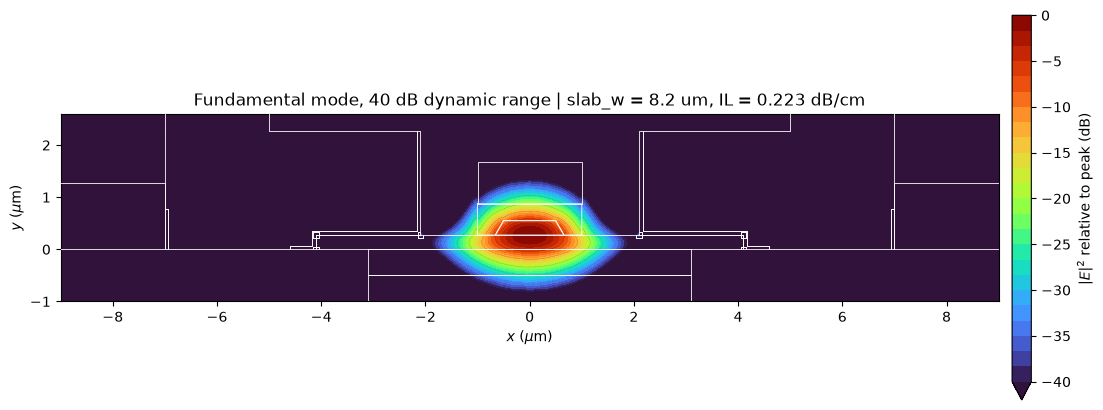

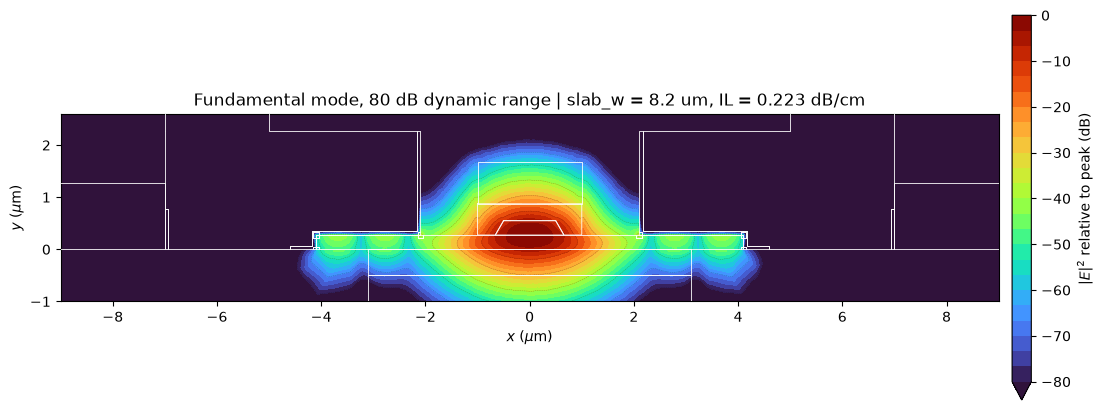

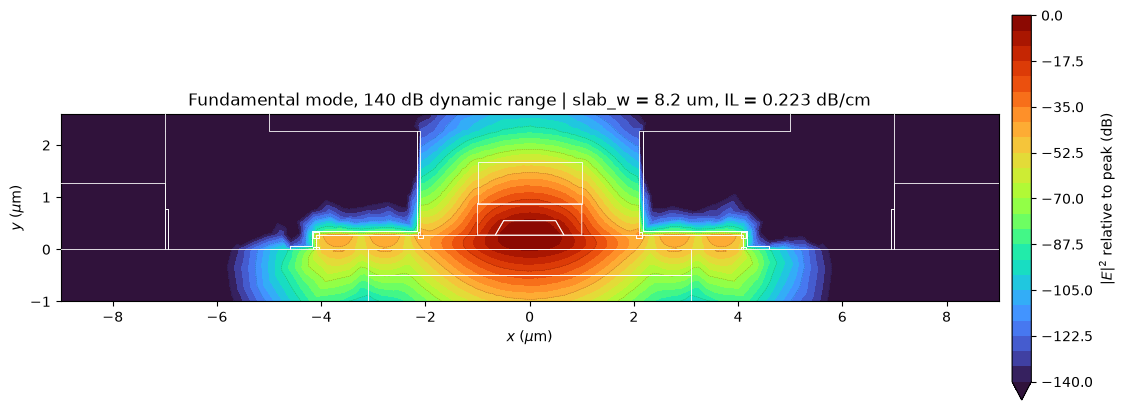

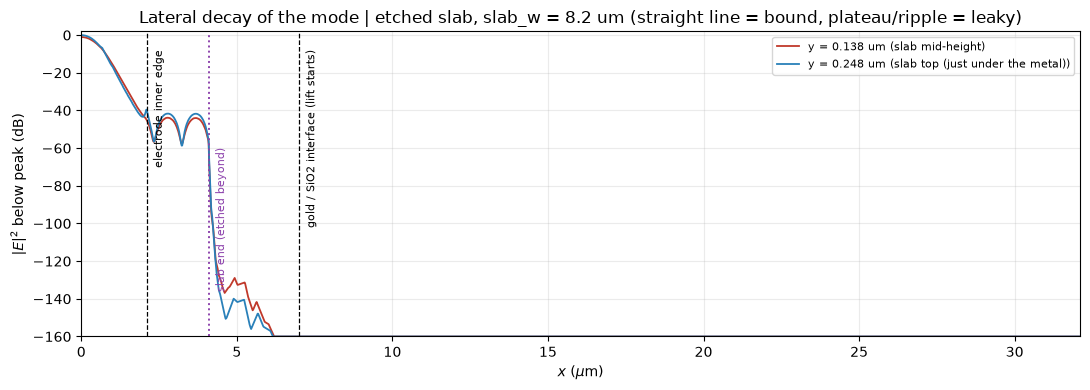

slab ends within 3 um of the gap edge: the far-field leak test needs a longer slab


In [6]:
# %% [5] Optical mode: dB contour map + lateral tail cut
# Place this as a NEW cell AFTER cell [4] (it needs `fund_mode`, `polygons`, `DEV_W`).
import matplotlib.tri as mtri


def _val(f):
    """DiscreteField -> ndarray, tolerant of skfem version differences."""
    return np.asarray(f.value if hasattr(f, "value") else f)


# ---- total intensity |E|^2 per element, then averaged onto nodes -----------
_Ei = fund_mode.basis.interpolate(fund_mode.E)
_Et, _Ez = _val(_Ei[0]), _val(_Ei[1])
I_el = (np.mean(np.abs(_Et[0]) ** 2, axis=-1)
        + np.mean(np.abs(_Et[1]) ** 2, axis=-1)
        + np.mean(np.abs(_Ez) ** 2, axis=-1))

I_nodal = np.zeros(skfem_mesh.p.shape[1])
_cnt = np.zeros(skfem_mesh.p.shape[1])
for _i in range(skfem_mesh.t.shape[0]):
    np.add.at(I_nodal, skfem_mesh.t[_i], I_el)
    np.add.at(_cnt, skfem_mesh.t[_i], 1.0)
I_nodal /= np.maximum(_cnt, 1.0)

I_dB = 10.0 * np.log10(np.maximum(I_nodal / I_nodal.max(), 1e-16))
_tri = mtri.Triangulation(skfem_mesh.p[0], skfem_mesh.p[1], skfem_mesh.t.T)
_interp = mtri.LinearTriInterpolator(_tri, I_dB)


def _outline(ax, lw=0.7, color="white", alpha=0.85):
    """Draw material boundaries so the contours can be read against geometry."""
    for _nm, _pg in polygons.items():
        if _nm.startswith(("clad", "box_far", "slab_far", "buf_far")):
            continue
        for _part in (_pg.geoms if _pg.geom_type == "MultiPolygon" else [_pg]):
            _xy = np.asarray(_part.exterior.coords)
            ax.plot(_xy[:, 0], _xy[:, 1], lw=lw, color=color, alpha=alpha, zorder=5)


def plot_mode_db(dyn_db=60.0, xlim=(-9.0, 9.0), ylim=(-1.0, 2.6),
                 n_levels=24, cmap="turbo"):
    """Contour the mode in dB below peak. Raise dyn_db to see deeper into the tails."""
    fig, ax = plt.subplots(figsize=(12, 4.2))
    lv = np.linspace(-abs(dyn_db), 0.0, n_levels + 1)
    cf = ax.tricontourf(_tri, I_dB, levels=lv, cmap=cmap, extend="min")
    ax.tricontour(_tri, I_dB, levels=lv[::4], colors="k", linewidths=0.3, alpha=0.35)
    _outline(ax)
    cb = fig.colorbar(cf, ax=ax, pad=0.012)
    cb.set_label(r"$|E|^2$ relative to peak (dB)")
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect("equal")
    ax.set_xlabel(r"$x$ ($\mu$m)"); ax.set_ylabel(r"$y$ ($\mu$m)")
    ax.set_title(rf"Fundamental mode, {dyn_db:.0f} dB dynamic range | "
                 rf"slab_w = {SLAB_W:.1f} um, IL = {att_opt_dB_cm:.3f} dB/cm")
    plt.tight_layout(); plt.show()


# Interactive slider if ipywidgets is available; otherwise three fixed ranges.
try:
    from ipywidgets import interact, FloatSlider, fixed
    interact(plot_mode_db,
             dyn_db=FloatSlider(value=60, min=20, max=160, step=5,
                                description="dyn range (dB)", continuous_update=False),
             xlim=fixed((-9.0, 9.0)), ylim=fixed((-1.0, 2.6)),
             n_levels=fixed(24), cmap=fixed("turbo"))
except ImportError:
    # no ipywidgets: show three fixed ranges instead. Call plot_mode_db(dyn_db=...)
    # yourself, or widen xlim to (-25, 25) to see the full electrode span.
    for _d in (40, 80, 140):
        plot_mode_db(dyn_db=_d)


# ---- THE DIAGNOSTIC: lateral cut through the slab -------------------------
# A BOUND mode decays as a straight line in dB.
# A LEAKY mode decays, then flattens into a plateau / standing-wave ripple that
# runs all the way out under the electrodes.
fig, ax = plt.subplots(figsize=(11, 4.0))
x_max = GAP_BOT / 2.0 + EL_W          # out to the far edge of the electrode
for _y, _lab, _c in [(SLAB_H * 0.5, "slab mid-height", "#c0392b"),
                     (SLAB_H * 0.9, "slab top (just under the metal)", "#2980b9")]:
    _xs = np.linspace(0.0, x_max, 2000)
    _v = _interp(_xs, np.full_like(_xs, _y))
    ax.plot(_xs, _v, lw=1.3, color=_c, label=f"y = {_y:.3f} um ({_lab})")

ax.axvline(GAP_BOT / 2.0, color="k", ls="--", lw=0.9)
ax.text(GAP_BOT / 2.0 + 0.2, -8, "electrode inner edge", fontsize=8, rotation=90, va="top")
ax.axvline(X_LIFT, color="k", ls="--", lw=0.9)
ax.text(X_LIFT + 0.2, -8, "gold / SiO2 interface (lift starts)",
        fontsize=8, rotation=90, va="top")
ax.axvline(SLAB_W / 2.0, color="#8e44ad", ls=":", lw=1.4)
ax.text(SLAB_W / 2.0 + 0.2, -60, "slab end (etched beyond)", color="#8e44ad",
        fontsize=8, rotation=90, va="top")
ax.set_xlabel(r"$x$ ($\mu$m)"); ax.set_ylabel(r"$|E|^2$ below peak (dB)")
ax.set_ylim(-160, 2); ax.set_xlim(0, x_max)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
ax.set_title(rf"Lateral decay of the mode | etched slab, slab_w = {SLAB_W:.1f} um "
             rf"(straight line = bound, plateau/ripple = leaky)")
plt.tight_layout(); plt.show()

if SLAB_W / 2.0 > GAP_BOT / 2.0 + 3.2:
    # Quantify it: fit the decay slope over the first 3 um, then report the residual
    # level far out. A bound tail extrapolates to << the measured far-field level.
    _xs = np.linspace(GAP_BOT / 2.0, GAP_BOT / 2.0 + 3.0, 200)
    _v = np.asarray(_interp(_xs, np.full_like(_xs, SLAB_H * 0.5)))
    _ok = np.isfinite(_v)
    _slope = np.polyfit(_xs[_ok], _v[_ok], 1)[0]
    _x_far = min(GAP_BOT / 2.0 + 15.0, SLAB_W / 2.0 - 0.1)   # stay inside the slab
    _far = float(_interp(_x_far, SLAB_H * 0.5))
    _pred = float(np.polyval(np.polyfit(_xs[_ok], _v[_ok], 1), _x_far))
    print(f"near-field decay slope      : {_slope:.2f} dB/um")
    print(f"level at x = {_x_far:.1f} um  measured : {_far:.1f} dB")
    print(f"                  extrapolated bound : {_pred:.1f} dB")
    print(f"excess over a bound tail    : {_far - _pred:+.1f} dB"
          f"   <-- large positive => radiating, not evanescent")
else:
    print("slab ends within 3 um of the gap edge: the far-field leak test needs a longer slab")

Ex: max|Ex|/max|Ex| = 1.000   share of integral |E|^2 =  95.26 %   phase vs Ex: -0 deg
Ey: max|Ey|/max|Ex| = 0.183   share of integral |E|^2 =   0.57 %
Ez: max|Ez|/max|Ex| = 0.217   share of integral |E|^2 =   4.16 %
Ez in quadrature with Ex: |E|^2-weighted share of Ez in Im(Ez) = 100.0 %  (100 % = exactly 90 deg)


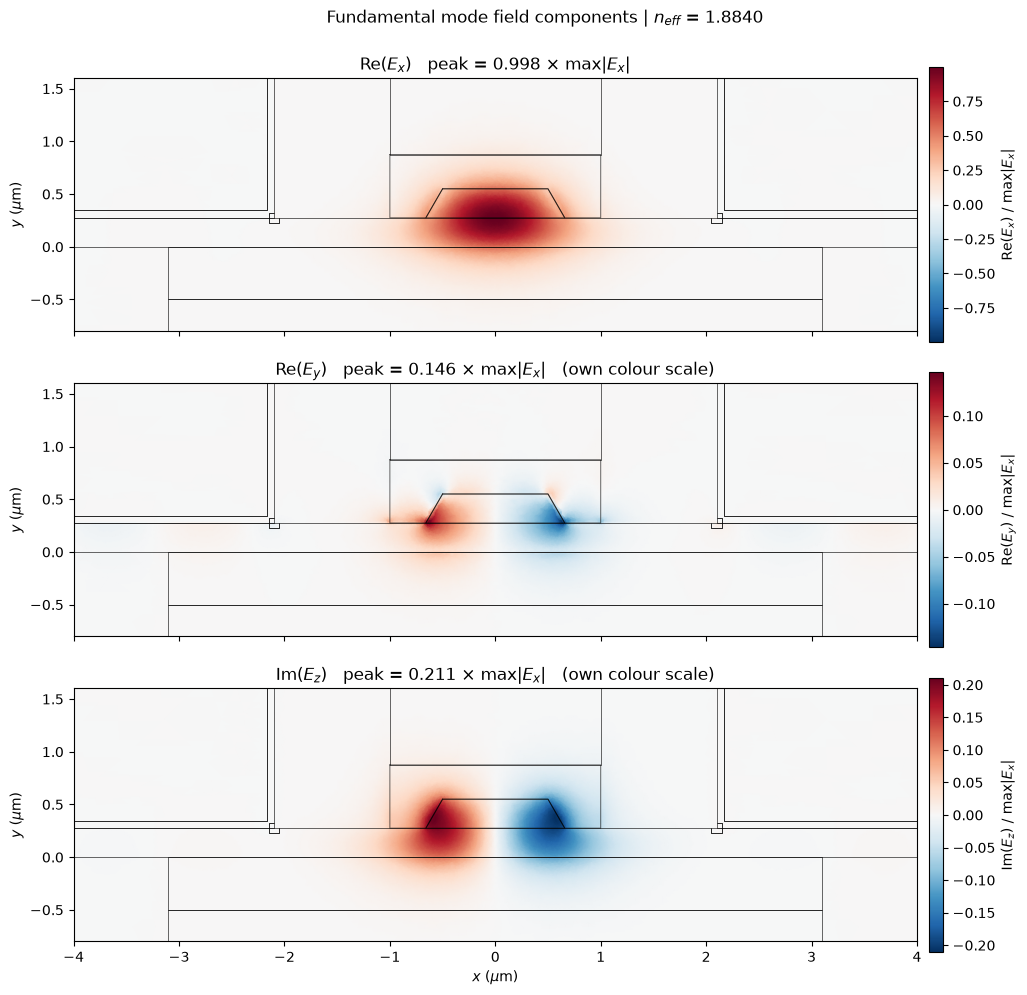

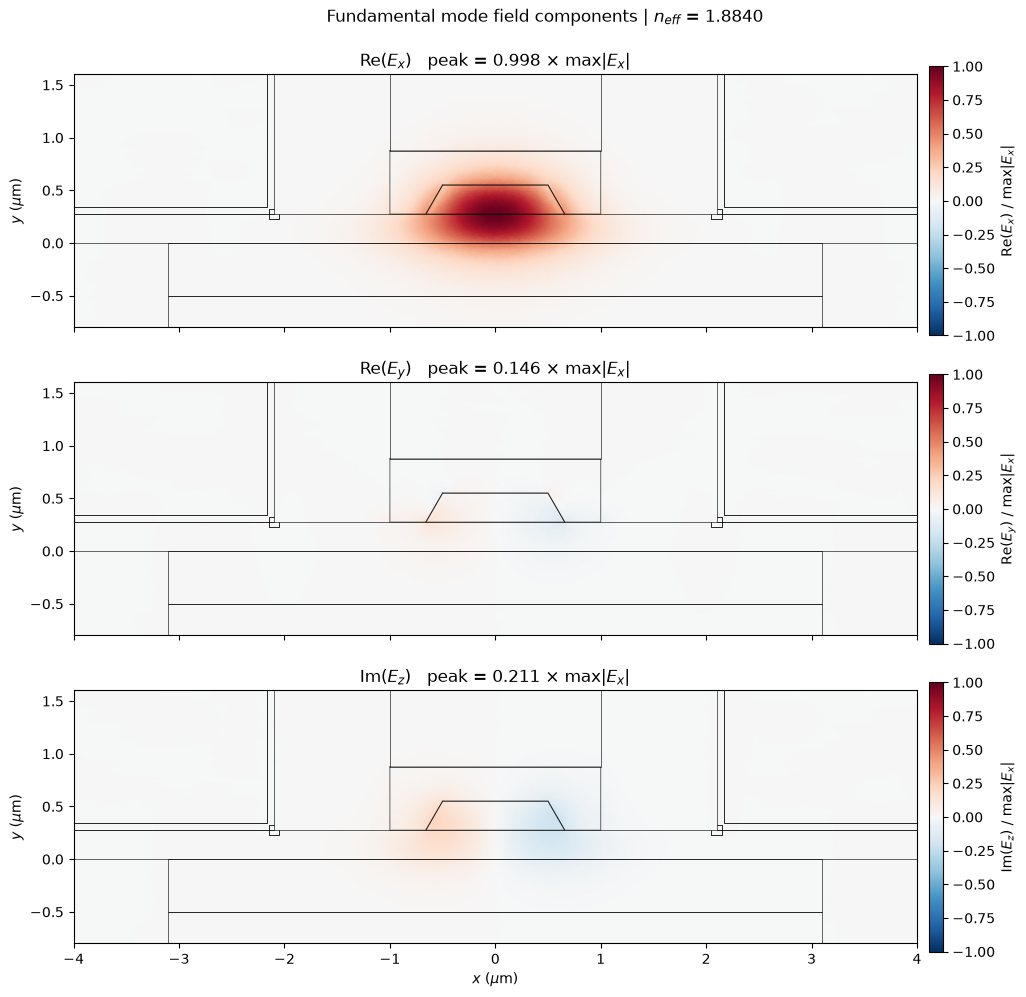

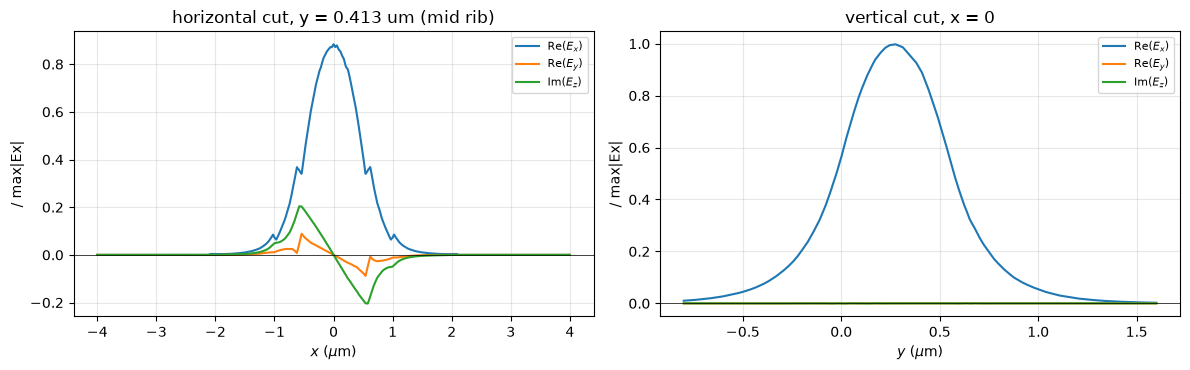

In [7]:
# %% [6] Field components Ex, Ey, Ez of the optical mode (signed, phase-referenced)
# The mode solver works on the 2D cross-section but solves for the FULL vector field of a
# mode E(x, y, z) = [Ex(x,y), Ey(x,y), Ez(x,y)] * exp(-j*beta*z): the z dependence is known
# analytically (exp(-j*beta*z)), so only the (x, y) profiles are unknowns. femwell discretises
# (Ex, Ey) with Nedelec (N1) edge elements and Ez with Lagrange (P1) nodal elements.
# femwell stores Ez already rescaled to its physical amplitude (it divides by j*beta/k0), so
# Ez is in quadrature (90 deg) with Et: after referencing the phase to Ex we plot Re(Ex),
# Re(Ey) and Im(Ez), all normalised to max|Ex|.
import matplotlib.tri as mtri
from matplotlib.colors import TwoSlopeNorm


def _v(f):
    return np.asarray(f.value if hasattr(f, "value") else f)


_Ei = fund_mode.basis.interpolate(fund_mode.E)
_Ex_q, _Ey_q, _Ez_q = _v(_Ei[0])[0], _v(_Ei[0])[1], _v(_Ei[1])      # (n_el, n_quad)

# global phase reference: make Ex real and positive at its maximum
_k = np.unravel_index(np.argmax(np.abs(_Ex_q)), _Ex_q.shape)
_ph = np.exp(-1j * np.angle(_Ex_q[_k]))
_A = np.abs(_Ex_q[_k])
_comp = {"Ex": _Ex_q * _ph / _A, "Ey": _Ey_q * _ph / _A, "Ez": _Ez_q * _ph / _A}


def _to_nodes(q):
    el = q.mean(axis=-1)
    out = np.zeros(skfem_mesh.p.shape[1], dtype=complex); cnt = np.zeros(skfem_mesh.p.shape[1])
    for i in range(skfem_mesh.t.shape[0]):
        np.add.at(out, skfem_mesh.t[i], el); np.add.at(cnt, skfem_mesh.t[i], 1.0)
    return out / np.maximum(cnt, 1.0)


_nod = {k: _to_nodes(v) for k, v in _comp.items()}
_trc = mtri.Triangulation(skfem_mesh.p[0], skfem_mesh.p[1], skfem_mesh.t.T)
_show = {"Ex": ("Re", _nod["Ex"].real), "Ey": ("Re", _nod["Ey"].real), "Ez": ("Im", _nod["Ez"].imag)}

# fraction of each component in the total |E|^2 (element-weighted, inside the window shown)
_area = 0.5 * np.abs((skfem_mesh.p[0, skfem_mesh.t[1]] - skfem_mesh.p[0, skfem_mesh.t[0]])
                     * (skfem_mesh.p[1, skfem_mesh.t[2]] - skfem_mesh.p[1, skfem_mesh.t[0]])
                     - (skfem_mesh.p[0, skfem_mesh.t[2]] - skfem_mesh.p[0, skfem_mesh.t[0]])
                     * (skfem_mesh.p[1, skfem_mesh.t[1]] - skfem_mesh.p[1, skfem_mesh.t[0]]))
_P = {k: float(np.sum(np.mean(np.abs(v) ** 2, axis=-1) * _area)) for k, v in _comp.items()}
_Ptot = sum(_P.values())
for k in _comp:
    _i = np.max(np.abs(_comp[k]))
    print(f"{k}: max|{k}|/max|Ex| = {_i:.3f}   share of integral |E|^2 = {_P[k] / _Ptot * 100:6.2f} %"
          + (f"   phase vs Ex: {np.angle(np.sum(_comp[k] * np.conj(_comp['Ex'])), deg=True):+.0f} deg" if k == "Ex" else ""))
_w = np.abs(_comp["Ez"]) ** 2
print(f"Ez in quadrature with Ex: |E|^2-weighted share of Ez in Im(Ez) = "
      f"{np.sum(_comp['Ez'].imag ** 2) / np.sum(_w) * 100:.1f} %  (100 % = exactly 90 deg)")


def plot_components(xlim=(-4.0, 4.0), ylim=(-0.8, 1.6), per_component_scale=True):
    fig, axs = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
    for ax, (k, (part, f)) in zip(axs, _show.items()):
        m = np.max(np.abs(f)) if per_component_scale else 1.0
        cf = ax.tripcolor(_trc, f, shading="gouraud", cmap="RdBu_r",
                          norm=TwoSlopeNorm(0.0, -m, m))
        _outline(ax, color="k", alpha=0.6)
        cb = fig.colorbar(cf, ax=ax, pad=0.012)
        cb.set_label(rf"{part}$(E_{k[1]})$ / max$|E_x|$")
        ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect("equal")
        ax.set_ylabel(r"$y$ ($\mu$m)")
        ax.set_title(rf"{part}($E_{k[1]}$)   peak = {np.max(np.abs(f)):.3f} $\times$ max$|E_x|$"
                     + ("   (own colour scale)" if per_component_scale and k != "Ex" else ""))
    axs[-1].set_xlabel(r"$x$ ($\mu$m)")
    fig.suptitle(rf"Fundamental mode field components | $n_{{eff}}$ = {np.real(n_eff):.4f}", y=0.995)
    plt.tight_layout(); plt.show()


plot_components()                              # each component on its own colour scale
plot_components(per_component_scale=False)     # common scale: true relative magnitudes

# ---- 1D cuts through the rib centre (y) and at mid-rib height (x) ---------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
_xs = np.linspace(-4, 4, 1601); _ys = np.linspace(-0.8, 1.6, 1201)
_yc = SLAB_H + WG_H / 2.0
for k, (part, f) in _show.items():
    it = mtri.LinearTriInterpolator(_trc, f)
    a1.plot(_xs, it(_xs, np.full_like(_xs, _yc)), label=rf"{part}($E_{k[1]}$)")
    a2.plot(_ys, it(np.zeros_like(_ys), _ys), label=rf"{part}($E_{k[1]}$)")
a1.set_xlabel(r"$x$ ($\mu$m)"); a1.set_title(rf"horizontal cut, y = {_yc:.3f} um (mid rib)")
a2.set_xlabel(r"$y$ ($\mu$m)"); a2.set_title("vertical cut, x = 0")
for a in (a1, a2):
    a.axhline(0, color="k", lw=0.5); a.grid(alpha=0.3); a.legend(fontsize=8); a.set_ylabel("/ max|Ex|")
plt.tight_layout(); plt.show()


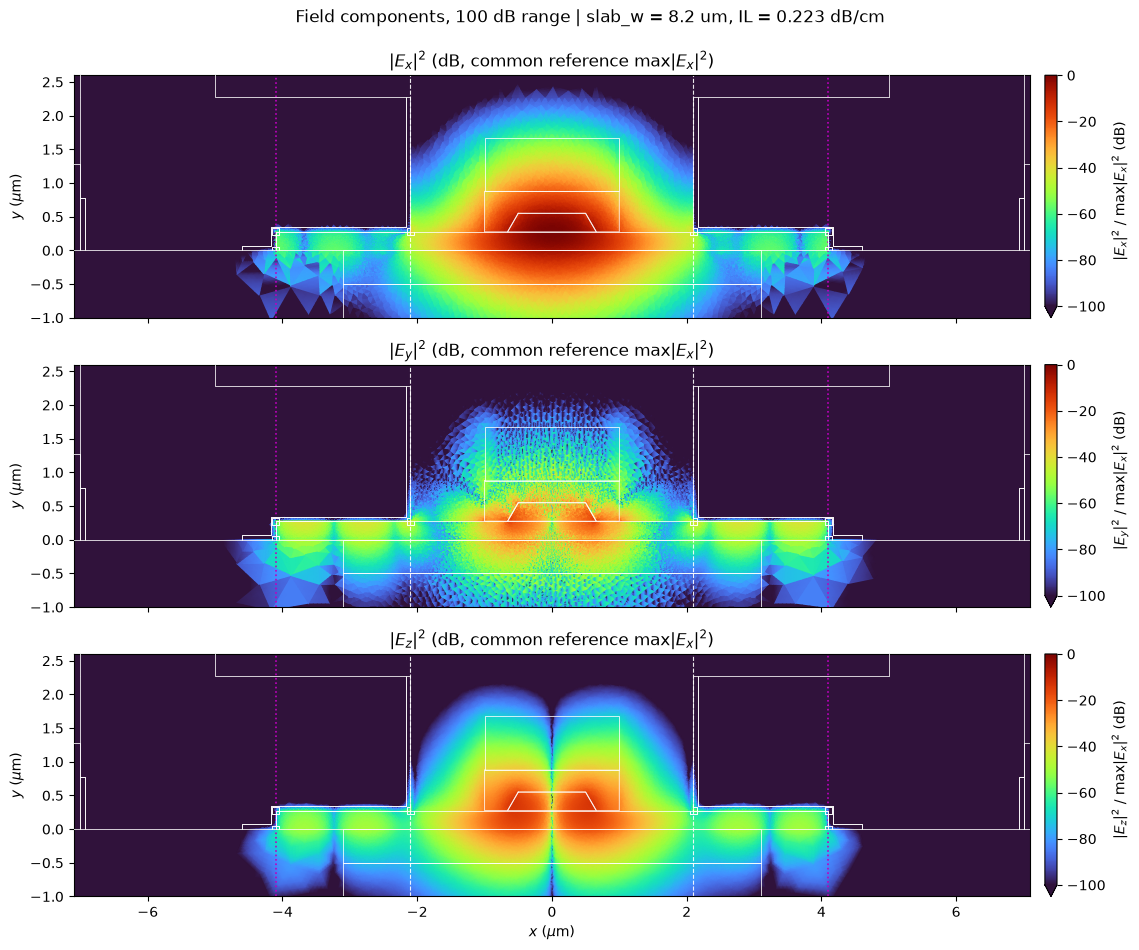

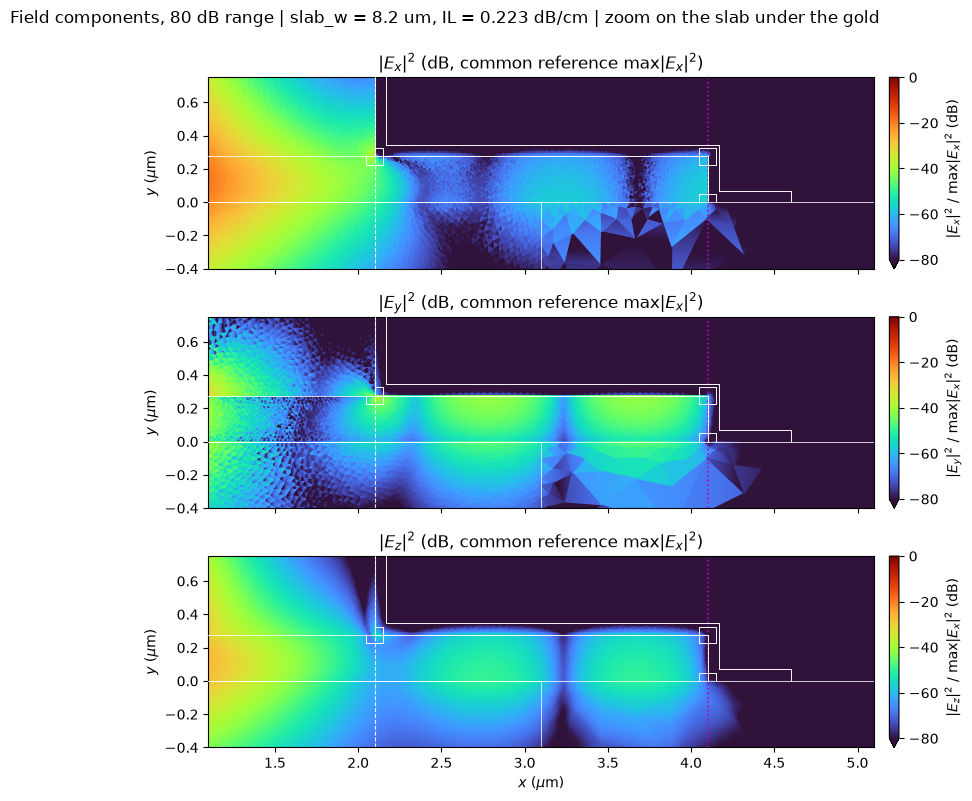

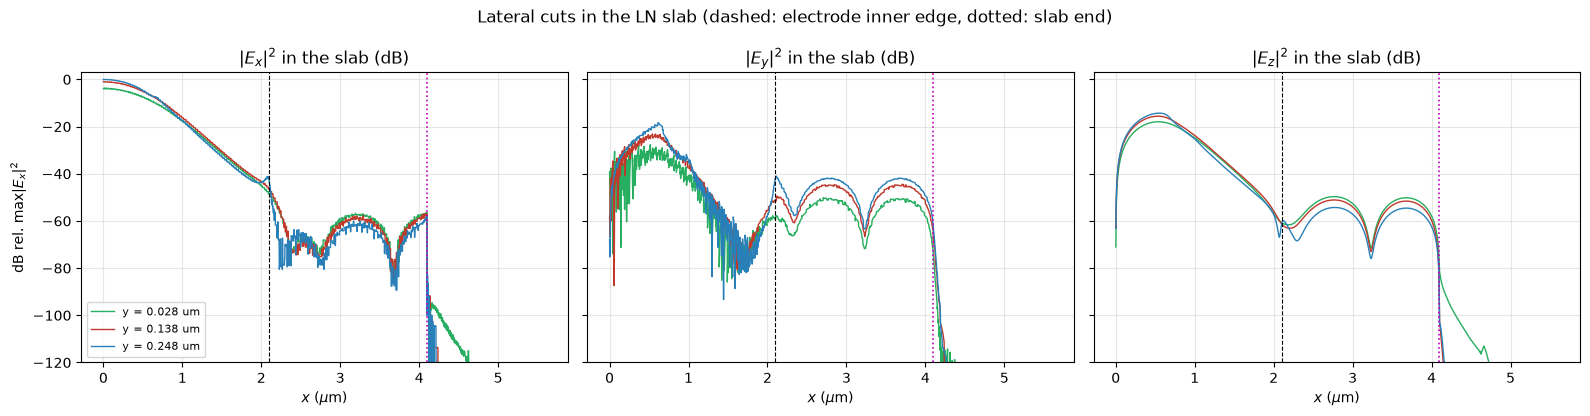

In [8]:
# %% [7] Field components in dB: whole section + zoom on the slab under the gold
# Same field as cell [6] (`_comp`: Ex, Ey, Ez phase-referenced to Ex, normalised to max|Ex|).
# Here we plot |E_i|^2 in dB relative to max|Ex|^2 (a log scale of the INTENSITY of each
# component), sampled finely inside every mesh triangle (no averaging onto nodes), so that
# jumps at interfaces stay sharp and the tails are not smeared or tiled.
#   - whole section : rib mode + evanescent tails + standing wave under the gold, 3 components
#   - zoom          : the slab between the electrode inner edge and the slab end
#   - lateral cuts  : |E_i|^2 (dB) along x at three heights in the slab, 3 components
import matplotlib.tri as mtri

# Plot-only refinement: the FEM field varies smoothly INSIDE each triangle (N1 for Ex, Ey,
# P1 for Ez). Instead of one averaged value per triangle, sample it at a lattice of points
# inside every triangle (N_SUB x N_SUB sub-triangles per element). Vertices are NOT shared
# between elements, so jumps at material interfaces stay sharp. The mesh and the solution
# are unchanged.
from skfem import Basis
N_SUB = 5
_ij = [(i, j) for j in range(N_SUB + 1) for i in range(N_SUB + 1 - j)]
_Xref = np.array([[i / N_SUB for i, j in _ij], [j / N_SUB for i, j in _ij]])
_idx = {p: n for n, p in enumerate(_ij)}
_loc = []
for j in range(N_SUB):
    for i in range(N_SUB - j):
        _loc.append((_idx[(i, j)], _idx[(i + 1, j)], _idx[(i, j + 1)]))
        if i + j < N_SUB - 1:
            _loc.append((_idx[(i + 1, j)], _idx[(i + 1, j + 1)], _idx[(i, j + 1)]))
_loc = np.array(_loc)
_bs = Basis(fund_mode.basis.mesh, fund_mode.basis.elem,
            quadrature=(_Xref, np.full(_Xref.shape[1], 1.0 / _Xref.shape[1])))
_Es = _bs.interpolate(fund_mode.E)
_sub = {"Ex": _v(_Es[0])[0], "Ey": _v(_Es[0])[1], "Ez": _v(_Es[1])}          # (n_el, n_pts)
_sub = {k: v * _ph / _A for k, v in _sub.items()}                              # same reference as cell [6]
_xg = _bs.mapping.F(_Xref)                                                      # (2, n_el, n_pts)
_ne, _npt = _sub["Ex"].shape
_PX, _PY = _xg[0].ravel(), _xg[1].ravel()
_T = (np.arange(_ne)[:, None, None] * _npt + _loc[None]).reshape(-1, 3)
_dB_sub = {k: 10.0 * np.log10(np.maximum(np.abs(v).ravel() ** 2, 1e-30)) for k, v in _sub.items()}
_tri_sub = mtri.Triangulation(_PX, _PY, _T)
_finder = mtri.Triangulation(skfem_mesh.p[0], skfem_mesh.p[1], skfem_mesh.t.T).get_trifinder()


def _cut_dB(k, xs, ys):
    """|E_k|^2 (dB) at points: locate the FEM triangle, then interpolate inside its sub-lattice."""
    e = _finder(xs, ys); ok = e >= 0; e0 = np.maximum(e, 0)
    p = skfem_mesh.p[:, skfem_mesh.t[:, e0]]                                  # (2, 3, n)
    J = np.stack([p[:, 1] - p[:, 0], p[:, 2] - p[:, 0]], axis=-1)            # (2, n, 2)
    rhs = np.stack([xs - p[0, 0], ys - p[1, 0]])                              # (2, n)
    det = J[0, :, 0] * J[1, :, 1] - J[0, :, 1] * J[1, :, 0]
    xi = (J[1, :, 1] * rhs[0] - J[0, :, 1] * rhs[1]) / det * N_SUB
    et = (-J[1, :, 0] * rhs[0] + J[0, :, 0] * rhs[1]) / det * N_SUB
    i0 = np.clip(np.floor(xi), 0, N_SUB - 1).astype(int); j0 = np.clip(np.floor(et), 0, N_SUB - 1).astype(int)
    fx, fy = xi - i0, et - j0
    up = (fx + fy > 1.0) & (i0 + j0 < N_SUB - 1)
    i0 = np.minimum(i0, N_SUB - 1 - j0)
    V = _dB_sub[k].reshape(_ne, _npt)
    g = lambda i, j: V[e0, np.array([_idx[(a, b)] for a, b in zip(i, j)])]
    lo = (1 - fx - fy) * g(i0, j0) + fx * g(np.minimum(i0 + 1, N_SUB - j0), j0) + fy * g(i0, np.minimum(j0 + 1, N_SUB - i0))
    i1, j1 = np.minimum(i0 + 1, N_SUB), np.minimum(j0 + 1, N_SUB)
    hi = (fx + fy - 1) * g(np.minimum(i1, N_SUB - j1), j1) + (1 - fy) * g(np.minimum(i1, N_SUB - j0), j0) \
        + (1 - fx) * g(np.minimum(i0, N_SUB - j1), j1)
    return np.where(ok, np.where(up, hi, lo), np.nan)


def _window(xlim, ylim, pad=0.5):
    cx, cy = _PX[_T].mean(axis=1), _PY[_T].mean(axis=1)
    return ~((cx > xlim[0] - pad) & (cx < xlim[1] + pad) & (cy > ylim[0] - pad) & (cy < ylim[1] + pad))


def plot_components_db(xlim, ylim, dyn_db=80.0, title_extra="", figsize=(13, 9.5)):
    fig, axs = plt.subplots(3, 1, figsize=figsize, sharex=True)
    _mask = _window(xlim, ylim)
    for ax, k in zip(axs, ("Ex", "Ey", "Ez")):
        _t = mtri.Triangulation(_PX, _PY, _T, mask=_mask)
        tp = ax.tripcolor(_t, _dB_sub[k], cmap="turbo", vmin=-abs(dyn_db), vmax=0.0,
                          shading="gouraud", rasterized=True)
        _outline(ax, color="w", alpha=0.8)
        cb = fig.colorbar(tp, ax=ax, pad=0.012, extend="min")
        cb.set_label(rf"$|E_{k[1]}|^2$ / max$|E_x|^2$ (dB)")
        ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect("equal")
        ax.set_ylabel(r"$y$ ($\mu$m)")
        ax.set_title(rf"$|E_{k[1]}|^2$ (dB, common reference max$|E_x|^2$)")
    for ax in axs:
        for _x in (GAP_BOT / 2.0, -GAP_BOT / 2.0):
            ax.axvline(_x, color="w", ls="--", lw=0.8, alpha=0.9)
        for _x in (SLAB_W / 2.0, -SLAB_W / 2.0):
            ax.axvline(_x, color="m", ls=":", lw=1.2)
    axs[-1].set_xlabel(r"$x$ ($\mu$m)")
    fig.suptitle(rf"Field components, {dyn_db:.0f} dB range | slab_w = {SLAB_W:.1f} um, "
                 rf"IL = {att_opt_dB_cm:.3f} dB/cm {title_extra}", y=0.995)
    plt.tight_layout(); plt.show()


# 1) whole section (white dashed: electrode inner edges, magenta dotted: slab ends)
plot_components_db(xlim=(-SLAB_W / 2.0 - 3.0, SLAB_W / 2.0 + 3.0), ylim=(-1.0, 2.6), dyn_db=100.0)

# 2) zoom on the standing-wave region: slab under the right electrode
_x0, _x1 = GAP_BOT / 2.0 - 1.0, SLAB_W / 2.0 + 1.0
plot_components_db(xlim=(_x0, _x1), ylim=(-0.4, 0.75), dyn_db=80.0,
                   title_extra="| zoom on the slab under the gold", figsize=(13, 8))

# 3) lateral cuts through the slab, read from the sub-sampled FEM field
_xs = np.linspace(0.0, SLAB_W / 2.0 + 1.5, 4000)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, k in zip(axs, ("Ex", "Ey", "Ez")):
    for _y, _c in ((SLAB_H * 0.1, "#27ae60"), (SLAB_H * 0.5, "#c0392b"), (SLAB_H * 0.9, "#2980b9")):
        _val = _cut_dB(k, _xs, np.full_like(_xs, _y))
        ax.plot(_xs, _val, lw=1.0, color=_c, label=f"y = {_y:.3f} um")
    ax.axvline(GAP_BOT / 2.0, color="k", ls="--", lw=0.8)
    ax.axvline(SLAB_W / 2.0, color="m", ls=":", lw=1.2)
    ax.set_title(rf"$|E_{k[1]}|^2$ in the slab (dB)"); ax.set_xlabel(r"$x$ ($\mu$m)")
    ax.grid(alpha=0.3); ax.set_ylim(-120, 3)
axs[0].set_ylabel(r"dB rel. max$|E_x|^2$"); axs[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Lateral cuts in the LN slab (dashed: electrode inner edge, dotted: slab end)")
plt.tight_layout(); plt.show()
